```{contents}
```
## Residual Connection + Layer Normalization

These two mechanisms are **critical** for:

* Stabilizing deep models,
* Speeding up convergence, and
* Preventing vanishing gradients.

---

### Where They Appear

Each **encoder** and **decoder** sublayer (like Attention or Feed-Forward) has this structure:

$$
\text{Output} = \text{LayerNorm}(x + \text{Sublayer}(x))
$$

So for every sub-layer (e.g., self-attention or FFN):

* Input (x) goes **directly** around (residual path),
* Output of the sublayer is **added back** to (x),
* The sum is then **normalized** using **LayerNorm**.

---

### Why Residual Connections Are Needed

Without residuals, deep networks suffer from:

* **Vanishing gradients:** gradients shrink as they backpropagate through many layers, leading to poor learning.
* **Degradation:** as layers increase, accuracy drops (not due to overfitting but because deeper models fail to train properly).

Residuals solve this by creating **shortcut paths** for gradient flow.

---

### Intuition

If a layer doesn’t help, the model can **learn the identity function** — i.e., skip it entirely.

This ensures:

> “Each new layer only learns a refinement of the previous one.”

---

### Mathematical Formulation

For a given sublayer $F(x)$ (like attention or FFN):

$$
y = \text{LayerNorm}(x + F(x))
$$

Here:

* (x): input to the sublayer
* (F(x)): transformation (e.g., Multi-Head Attention or FFN output)
* (x + F(x)): **residual connection**
* `LayerNorm`: stabilizes scaling differences

---

### Gradient Benefit (Core Insight)

During backpropagation:
$$
\frac{\partial y}{\partial x} = I + \frac{\partial F(x)}{\partial x}
$$

That **identity matrix term (I)** means gradients can flow directly,
bypassing the nonlinear layers — preventing vanishing gradients.

---

### Layer Normalization

After adding residuals, we apply **LayerNorm**.

This keeps activations **stable** and **centered**, especially since residual sums can change the scale of inputs.

---

### **LayerNorm Formula**

Given an input vector $x = [x_1, x_2, ..., x_d]$,
LayerNorm normalizes across the *features* (not batch):

$$
\text{LayerNorm}(x) = \gamma \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta
$$

Where:

* $\mu = \frac{1}{d}\sum_i x_i$ (mean)
* $\sigma^2 = \frac{1}{d}\sum_i (x_i - \mu)^2$ (variance)
* $\gamma, \beta$ are learnable scaling parameters

---

### Why Not BatchNorm?

| LayerNorm                                      | BatchNorm                             |
| ---------------------------------------------- | ------------------------------------- |
| Normalizes **across features**                 | Normalizes **across batch dimension** |
| Works well with **variable sequence lengths**  | Requires consistent batch statistics  |
| **No batch dependency** (works for 1 sentence) | Depends on other samples in batch     |

Transformers use **LayerNorm** since batch sizes and sequence lengths often vary in NLP.

---

### Step-by-Step Example

#### Suppose:

Input vector $x = [1, 2, 3]$,
Sublayer output $F(x) = [0.5, -1, 1.5]$

1. **Residual addition:**
   $$
   x + F(x) = [1.5, 1, 4.5]
   $$

2. **Mean (μ):**
   $$
   \mu = (1.5 + 1 + 4.5)/3 = 2.33
   $$

3. **Variance (σ²):**
   $$
   σ² = ((1.5-2.33)^2 + (1-2.33)^2 + (4.5-2.33)^2)/3 = 2.56
   $$

4. **Normalization:**
   $$
   (x - μ)/\sqrt{σ² + ε} ≈ [-0.52, -0.83, 1.35]
   $$

5. **Scale + Shift:**
   $$
   y = γ \cdot \text{normalized} + β
   $$

Now $y$ has zero mean, unit variance — **stable for the next layer.**

---

### Visualization (Matplotlib Example)



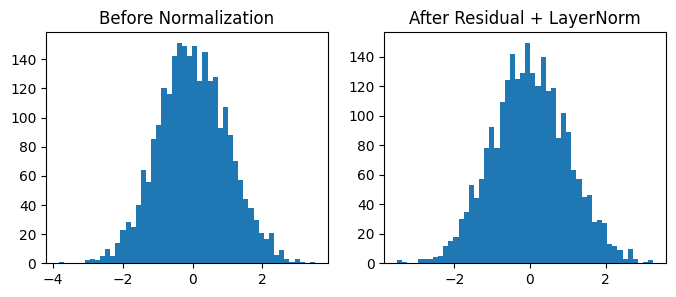

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

x = torch.randn(5, 512)              # input tensor
sublayer = nn.Linear(512, 512)
layer_norm = nn.LayerNorm(512)

y = layer_norm(x + sublayer(x))      # residual + layernorm

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.hist(x.flatten().detach().numpy(), bins=50)
plt.title("Before Normalization")

plt.subplot(1,2,2)
plt.hist(y.flatten().detach().numpy(), bins=50)
plt.title("After Residual + LayerNorm")
plt.show()



### Example Calculation 

Suppose a token embedding (for word “Cat”) is:
$$
x = [2, 4, 6, 8]
$$
and the sublayer output (say, after attention) is:
$$
F(x) = [1, -1, 2, 0]
$$

Then:

### Step 1: Add residual

$$
x + F(x) = [3, 3, 8, 8]
$$

### Step 2: LayerNorm

Mean:
$$
\mu = (3 + 3 + 8 + 8) / 4 = 5.5
$$

Variance:
$$
\sigma^2 = \frac{1}{4}[(3-5.5)^2 + (3-5.5)^2 + (8-5.5)^2 + (8-5.5)^2] = 6.25
$$

Normalize:
$$
(x_i - \mu) / \sqrt{\sigma^2 + \epsilon}
$$

Result (approx):
$$
[-1.0, -1.0, 1.0, 1.0]
$$

Then apply:
$$
y = \gamma * \text{normalized} + \beta
$$

If $\gamma=1, \beta=0$:

$$
y = [-1, -1, 1, 1]
$$

That’s the normalized, stabilized output vector.



You’ll see that **after normalization**, activations are centered (mean ≈ 0, variance ≈ 1) — ensuring stable learning.

---

### Where It Appears in Transformer Layers

Each encoder (and decoder) block uses **two** such residual-normalization pairs:

#### Encoder:

```
x → Multi-Head Attention → Add + LayerNorm → FFN → Add + LayerNorm
```

#### Decoder:

```
x → Masked Attention → Add + LayerNorm
   → Encoder-Decoder Attention → Add + LayerNorm
   → FFN → Add + LayerNorm
```

---

**Benefits Summary**

| Mechanism               | Role                                | Effect                                               |
| ----------------------- | ----------------------------------- | ---------------------------------------------------- |
| **Residual Connection** | Shortcut for gradients              | Prevents vanishing; faster convergence               |
| **LayerNorm**           | Normalizes feature distributions    | Stabilizes activations; prevents exploding gradients |
| **Together**            | Maintain scale and information flow | Enables very deep training (6–48+ layers)            |

---

### In Short:

> **Residual Connection:** keeps old information alive and stabilizes gradients.
> **Layer Normalization:** keeps new activations numerically stable.
> Together, they make deep Transformers **trainable, stable, and efficient.**
